# Stationary baseline analysis

Use this notebook to inspect sensor noise, DC removal, RMS, and window statistics while the monitored surface is stationary. These measurements establish the baseline used when selecting the idle threshold.

> The notebook is exploratory. Reusable feature calculations belong in `src/machine_sentinel/features.py`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../../data/raw/stationary.csv')

In [3]:
df.head()

,timestamp_us,ax,ay,az,time_s
0,626457,318,38,4882,NaN
1,631437,297,22,4888,NaN
2,636436,312,16,4887,NaN
3,641436,295,8,4904,NaN
4,646438,282,15,4866,NaN


In [4]:
df.shape

(6800, 5)

In [5]:
df['time_s'] = (df['timestamp_us'] - df['timestamp_us'][0]) / 1000000

In [6]:
df.head()

,timestamp_us,ax,ay,az,time_s
0,626457,318,38,4882,0.000000
1,631437,297,22,4888,0.004980
2,636436,312,16,4887,0.009979
3,641436,295,8,4904,0.014979
4,646438,282,15,4866,0.019981


In [7]:
acceleration = df['az']
time = df['time_s']

Text(0, 0.5, 'Raw Z Acceleration (counts)')

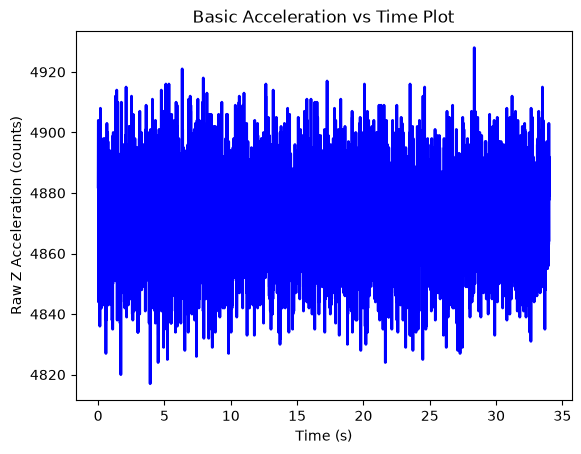

In [8]:
plt.plot(time, acceleration, label="Accl vs Time", color='b', lw=2)
plt.title('Basic Acceleration vs Time Plot')
plt.xlabel('Time (s)')
plt.ylabel('Raw Z Acceleration (counts)')

In [9]:
mean = np.mean(acceleration)
standard_deviation = np.std(acceleration)
peak_to_peak = np.ptp(acceleration)
rms = np.sqrt(np.mean(np.square(acceleration)))

In [10]:
print(f"Mean: {mean}")  
print(f"Standard Deviation: {standard_deviation}")
print(f"Peak-to-Peak: {peak_to_peak}")
print(f"RMS: {rms}")

Mean: 4871.6610294117645
Standard Deviation: 14.778699262164038
Peak-to-Peak: 111
RMS: 4871.683445734255


In [11]:
z_centered = acceleration - mean

Text(0, 0.5, 'Z-Centered Acceleration')

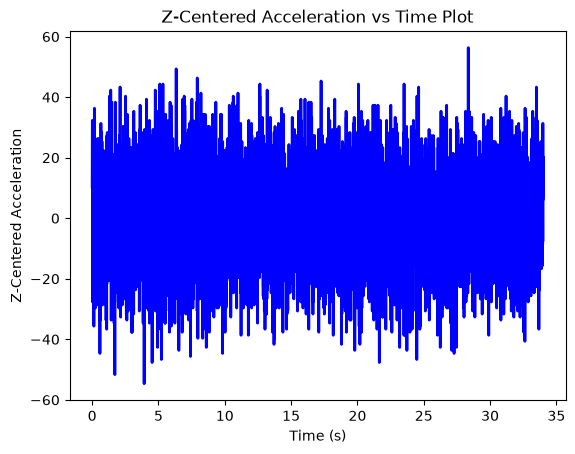

In [12]:
plt.plot(time, z_centered, label="Accl vs Time", color='b', lw=2)
plt.title('Z-Centered Acceleration vs Time Plot')
plt.xlabel('Time (s)')
plt.ylabel('Z-Centered Acceleration')

In [13]:
rms_z_centered = np.sqrt(np.mean(np.square(z_centered)))
print(f"RMS of Z-Centered Acceleration: {rms_z_centered}")
print(f"Standard Deviation of Z-Centered Acceleration: {np.std(z_centered)}")
print(f"Peak-to-Peak of Z-Centered Acceleration: {np.ptp(z_centered)}")
print(f"Mean of Z-Centered Acceleration: {np.mean(z_centered)}")

RMS of Z-Centered Acceleration: 14.778699262164038
Standard Deviation of Z-Centered Acceleration: 14.778699262164038
Peak-to-Peak of Z-Centered Acceleration: 111.0
Mean of Z-Centered Acceleration: 2.0329881569041926e-13


In [14]:
WINDOW_SIZE = 200  
data = []  

for start in range(0, len(df), WINDOW_SIZE):     
    end = min(start + WINDOW_SIZE, len(df))      
    window = df.iloc[start:end]     
    
    # Convert to g's securely
    z_g = window['az'] / 4096.0  
    
    # Calculate statistics
    z_centered_window = z_g - z_g.mean()     
    rms_window = np.sqrt(np.mean(np.square(z_centered_window)))     
    std_window = z_centered_window.std()     
    
    # Fixed: Use max - min instead of np.ptp to ensure safe Pandas compatibility
    ptp_window = z_g.max() - z_g.min()      

    data.append({         
        'start_idx': start,
        'end_idx': end,
        'rms': rms_window,         
        'std': std_window,         
        'ptp': ptp_window,         
        'condition': 'stationary'     
    })  

window_stats = pd.DataFrame(data)

In [15]:
window_stats.head()

,start_idx,end_idx,rms,std,ptp,condition
0,0,200,0.003607,0.003616,0.019775,stationary
1,200,400,0.003593,0.003602,0.022949,stationary
2,400,600,0.003774,0.003784,0.019775,stationary
3,600,800,0.003788,0.003798,0.022461,stationary
4,800,1000,0.003595,0.003604,0.021973,stationary
